# EDA: val.csv

This notebook performs exploratory data analysis on `data/hackathon-recover-x-cogito/val.csv`.
Sections:
- Import libraries
- Load and inspect data
- Missing values
- Data types and conversions
- Univariate analysis
- (later) Bivariate / Multivariate, Save processed data

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')
from IPython.display import display

## Load and Inspect Data
Load `val.csv` and show a quick summary (head, shape, dtypes).

In [2]:
file_path = "../data/hackathon-recover-x-cogito/val.csv"
val = pd.read_csv(file_path)
print('Shape:', val.shape)
val.head()


Shape: (111384, 5)


,id,project_id,room,work_operation_cluster_name,work_operation_cluster_code
0,203934,187007,Kjøkken,Annet__Sanering__Sotgrad,386
1,203935,226635,Soverom 2,Intern flytting av innbo mellom rom,204
2,203935,226635,Soverom 2,Demont innv karmlist,7
3,203935,226635,Soverom 2,Ny underlag for parkett/laminat,53
4,203935,226635,Soverom 2,Grovrengjøring og desinfisering av overflater,104


## Missing Values
Identify and visualize missingness.

In [3]:
mv = val.isnull().sum().sort_values(ascending=False)
mv_percent = (val.isnull().mean()*100).sort_values(ascending=False)
missing_df = pd.concat([mv, mv_percent], axis=1)
missing_df.columns = ['missing_count','missing_percent']
missing_df[missing_df['missing_count']>0].head(30)

# plot top missing
top_miss = missing_df[missing_df['missing_count']>0].head(20)
if not top_miss.empty:
    plt.figure(figsize=(10,6))
    sns.barplot(x=top_miss['missing_percent'], y=top_miss.index, palette='rocket')
    plt.xlabel('Percent missing')
    plt.title('Top missing columns in val.csv')
    plt.show()
else:
    print('No missing values in val.csv')


No missing values in val.csv


## Data types & Univariate Analysis
Try conversions and show distributions for numeric/categorical columns.

Numeric: 3, Categorical: 2


,count,mean,std,min,25%,50%,75%,max
id,111384.0,209333.536037,3112.446450,203934.0,206651.0,209334.0,211995.0,214760.0
project_id,111384.0,212288.067335,38352.692919,147524.0,177917.0,213312.0,245832.0,280355.0
work_operation_cluster_code,111384.0,141.218326,104.684701,0.0,55.0,124.0,211.0,387.0


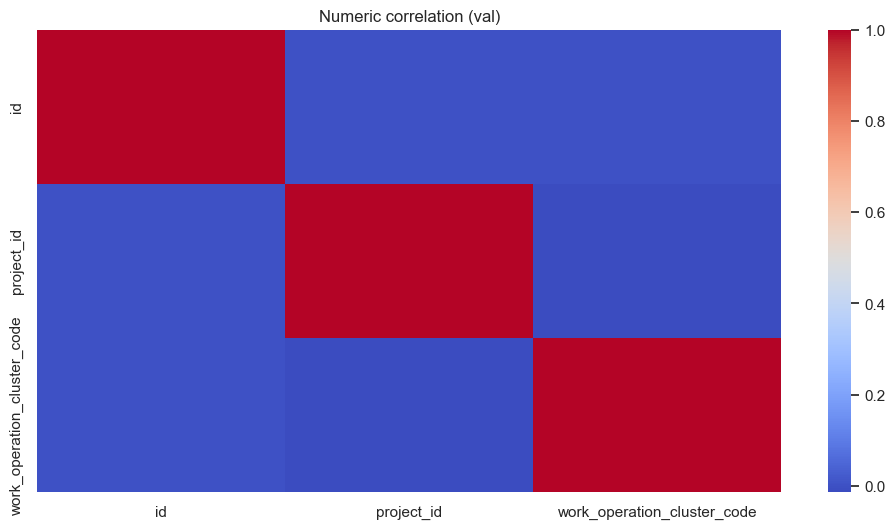

Top for room:


room
Kjøkken          15435
Stue             12594
Gang             11135
Soverom          10890
Bad               5740
Andre områder     5199
Bod               4437
Vaskerom          3262
Gang 2            2505
Soverom 2         2447
Wc                2205
Stue/kjøkken      2092
Kjeller           1607
Utvendig          1319
Bod 2             1054
Stue 2            1037
Kjøkken/stue       896
Kjellerstue        685
Bad 2              680
Gang 3             679
Name: count, dtype: int64

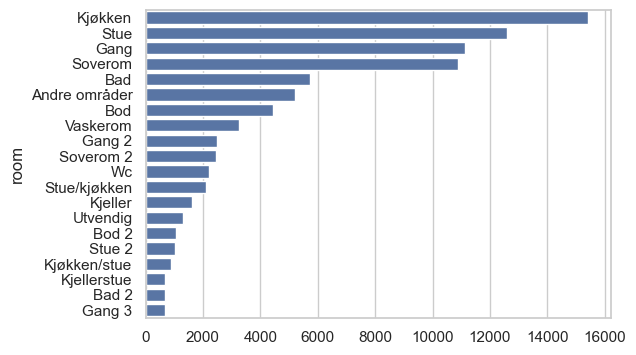

Top for work_operation_cluster_name:


work_operation_cluster_name
Lett beskyttelse av gulv med dekkepapp    4036
Byggvask                                  3499
Intern flytting av innbo mellom rom       3421
Ny gulvlist                               2992
Riv gulvlist                              2974
Ny gulv                                   2825
Ny spikerslag/kubbing                     2263
Kapping, tverrsaging av plater/panel      2165
Riv flytende gulv                         2162
Ny underlag for parkett/laminat           2150
Ny innv karmlist                          2146
Riv innv karmlist                         2059
Riv underlagsmateriale                    2049
Riv taklist                               1824
Ny taklister                              1796
Ny feielist                               1772
Ny dampsperre                             1727
Riv feielist                              1685
Riv dampsperre / vindsperre               1648
Ny isolasjon i vegg                       1486
Name: count, dtype: int64

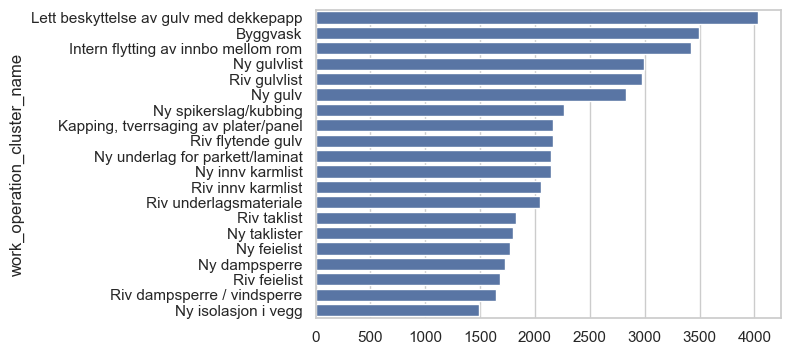

In [4]:
# Convert date-like columns
for c in val.columns:
    if 'date' in c.lower() or 'time' in c.lower():
        val[c] = pd.to_datetime(val[c], errors='coerce')

# Convert numeric-like object columns
for c in val.select_dtypes(include=['object']).columns:
    conv = pd.to_numeric(val[c].str.replace(',',''), errors='coerce')
    if conv.notnull().sum() >= len(val)*0.8:
        val[c] = conv
        print(f'Converted {c} to numeric')

# Univariate
num_cols = val.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = val.select_dtypes(include=['object','category']).columns.tolist()
print(f"Numeric: {len(num_cols)}, Categorical: {len(cat_cols)}")
if num_cols:
    display(val[num_cols].describe().T)
    plt.figure(figsize=(12,6))
    sns.heatmap(val[num_cols].corr(), annot=False, cmap='coolwarm')
    plt.title('Numeric correlation (val)')
    plt.show()

if cat_cols:
    for c in cat_cols[:8]:
        vc = val[c].value_counts(dropna=False).head(20)
        print(f"Top for {c}:")
        display(vc)
        plt.figure(figsize=(6, min(4, len(vc)*0.25+1)))
        sns.barplot(x=vc.values, y=vc.index)
        plt.show()
